# ECON 470 Homework 3.3
## Claire Hamilton

In [1]:
# Load packages

suppressPackageStartupMessages({
  library(tidyverse)
})

library(broom)
library(dplyr)
library(tibble)

In [2]:
# Check data

ma.full <- read_csv("../data/output/ma-full.csv", show_col_types = FALSE)

# glimpse(ma.full)

# Summarize the Data

## Question 1

In [3]:
q1 <- ma.full %>%
filter(!is.na(Star_Rating)) %>%
mutate(market_share = avg_enrollment / avg_eligibles) %>%
group_by(year) %>%
summarize(
    'Mean Star Rating' = round(mean(Star_Rating, na.rm = TRUE), 2),
    'Mean Enrollment' = round(mean(avg_enrollment, na.rm = TRUE), 2),
    'Mean Market Share' = round(mean(market_share, na.rm = TRUE), 4),
    'Plan Count' = n()
    )

q1

year,Mean Star Rating,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<dbl>,<int>
2010,2.97,346.99,0.0125,59579
2011,3.26,388.31,0.0151,55249
2012,3.36,410.65,0.0166,58169
2013,3.55,406.73,0.0163,64174
2014,3.81,451.11,0.0179,58636
2015,3.96,482.57,0.0193,60819


Star ratings, mean enrollments, and mean market shares tend to increase over time.

## Question 2

In [4]:
q2 <- ma.full %>%
filter(is.na(Star_Rating)) %>%
mutate(market_share = avg_enrollment / avg_eligibles) %>%
group_by(year) %>%
summarize(
    'Mean Enrollment' = round(mean(avg_enrollment, na.rm = TRUE), 2),
    'Mean Market Share' = round(mean(market_share, na.rm = TRUE), 4),
    'Plan Count' = n()
    )

q2

year,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<int>
2010,107.34,0.0092,48643
2011,167.90,0.0132,12754
2012,172.73,0.0119,9077
2013,213.50,0.0174,3661
2014,257.60,0.0158,3708
2015,314.21,0.0087,4680


The plans without a star rating tend to have lower average enrollments and market share compared to plans with a star rating. 

## Question 3

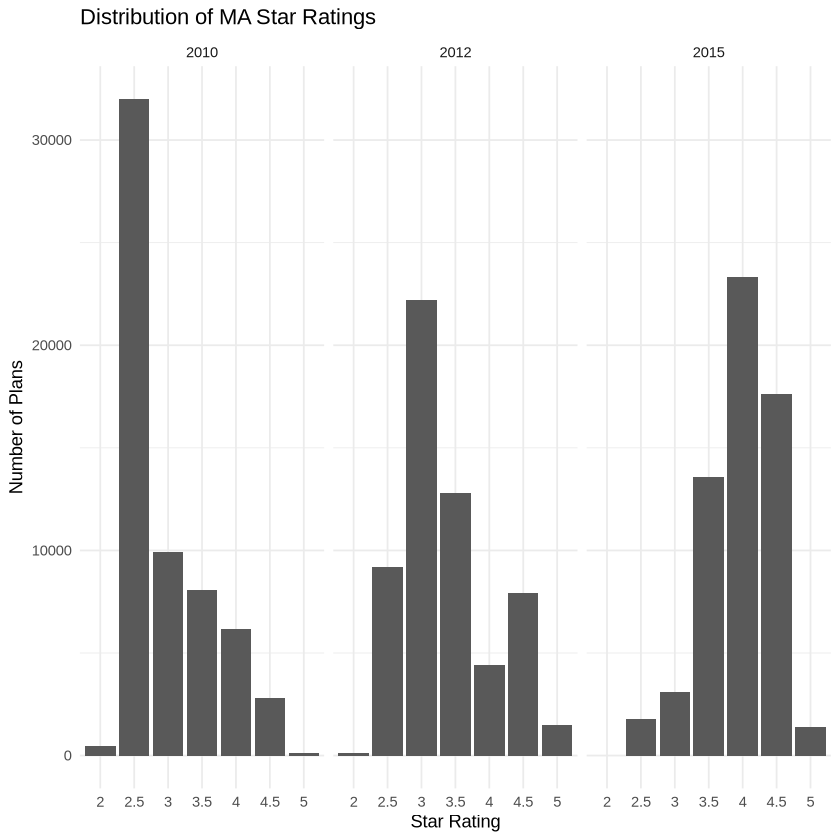

In [5]:
# Question 3

# Filter

stars_dist <- ma.full %>%
  filter(
    year %in% c(2010, 2012, 2015),
    !is.na(Star_Rating)
  )

# Bar graph

ggplot(stars_dist, aes(x = factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~year) +
  labs(
    title = "Distribution of MA Star Ratings",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
  theme_minimal()

The distribution of star ratings has shifted to the right over time, meaning plans received higher star ratings (on average) in later years.

## Question 4

In [6]:
# Indicator variables

ma.full <- ma.full %>%
  mutate(
    market_share = avg_enrollment / avg_enrolled
  )

ma.full <- ma.full %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating == 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45p = as.integer(Star_Rating >= 4.5)
  )

ma.full <- ma.full %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating == 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45p = as.integer(Star_Rating >= 4.5)
  )

reg_2010 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2010))

reg_2011 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2011))

reg_2012 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2012))

reg_2013 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2013))

reg_2014 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2014))

reg_2015 <- lm(market_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(ma.full, year == 2015))

suppressPackageStartupMessages(library(stargazer))

stargazer(reg_2010, reg_2011, reg_2012, reg_2013, reg_2014, reg_2015,
          type = "text",
          column.labels = c("2010","2011","2012","2013","2014","2015"),
          covariate.labels = c("3 Stars","3.5 Stars","4 Stars","4.5+ Stars"),
          dep.var.labels = "Market Share",
          omit.stat = c("f","ser"))


                               Dependent variable:                   
             --------------------------------------------------------
                                   Market Share                      
               2010      2011      2012      2013     2014     2015  
                (1)       (2)       (3)      (4)      (5)      (6)   
---------------------------------------------------------------------
3 Stars      0.013***  0.035***  0.031***  0.062*** 0.027*** 0.027***
              (0.002)   (0.002)   (0.003)  (0.003)  (0.006)  (0.005) 
                                                                     
3.5 Stars      0.001   0.019***  0.013***  0.038*** 0.027*** 0.039***
              (0.002)   (0.003)   (0.003)  (0.003)  (0.006)  (0.004) 
                                                                     
4 Stars       -0.004*    0.003   -0.025*** 0.017***  0.007   0.011***
              (0.002)   (0.003)   (0.004)  (0.003)  (0.006)  (0.004) 
                   

In general, higher star ratings are associated with greater market share across years.

# Estimate ATEs

## Question 5

In [13]:
# Question 5

data.2010 <- read.csv("../data/output/data-2010.csv")

data_cleaned <- data.2010 %>%
  mutate(
    raw_score = rowMeans(
      as.matrix(select(., breastcancer_screen:ttyt_available)),
      na.rm = TRUE
    ),
    star_from_raw = floor(raw_score * 2 + 0.5) / 2,
    rounded_up = (star_from_raw > floor(raw_score * 2) / 2)
  )

rounded_up_table <- data_cleaned %>%
  filter(star_from_raw %in% c(3, 3.5, 4, 4.5, 5)) %>%
  group_by(star_from_raw) %>%
  summarize(
    num_plans_rounded_up = sum(rounded_up, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  complete(star_from_raw = c(3, 3.5, 4, 4.5, 5),
           fill = list(num_plans_rounded_up = 0)) %>%
  arrange(star_from_raw) %>%
  rename(
    `Star Rating` = star_from_raw,
    `Plans Rounded Up` = num_plans_rounded_up
  )

rounded_up_table

Star Rating,Plans Rounded Up
<dbl>,<int>
3.0,4425
3.5,4605
4.0,5518
4.5,1095
5.0,30


## Question 6

In [39]:
data_cleaned <- data_cleaned %>%
  mutate(
    market_share = avg_enrollment / avg_enrolled
  )

star30 <- lm(
  market_share ~ treat * score,
  data = data_cleaned %>%
    filter(raw_score >= (2.75 - 0.125),
           raw_score <= (2.75 + 0.125),
           Star_Rating %in% c(2.5, 3.0)) %>%
    mutate(
      treat = as.integer(raw_score >= 2.75),
      score = raw_score - 2.75
    )
)

star35 <- lm(
  market_share ~ treat * score,
  data = data_cleaned %>%
    filter(raw_score >= (3.25 - 0.125),
           raw_score <= (3.25 + 0.125),
           Star_Rating %in% c(3.0, 3.5)) %>%
    mutate(
      treat = as.integer(raw_score >= 3.25),
      score = raw_score - 3.25
    )
)


rd_table <- bind_rows(
  tidy(star30) %>%
    select(term, estimate) %>%
    mutate(Cutoff = "3 Stars"),

  tidy(star35) %>%
    select(term, estimate) %>%
    mutate(Cutoff = "3.5 Stars")
) %>%
  pivot_wider(
    names_from = Cutoff,
    values_from = estimate
  ) %>%
  mutate(
    term = recode(term,
      "(Intercept)" = "Intercept",
      "treat" = "Rounded",
      "score" = "Running Score",
      "treat:score" = "Rounded × Score"
    )
  ) %>%
  rename(Coefficient = term)

rd_table

Coefficient,3 Stars,3.5 Stars
<chr>,<dbl>,<dbl>
Intercept,0.01628645,0.10228759
Rounded,0.05460050,-0.03953024
Running Score,-0.74027583,0.41673292
Rounded × Score,0.95797817,-0.46739451


## Question 7

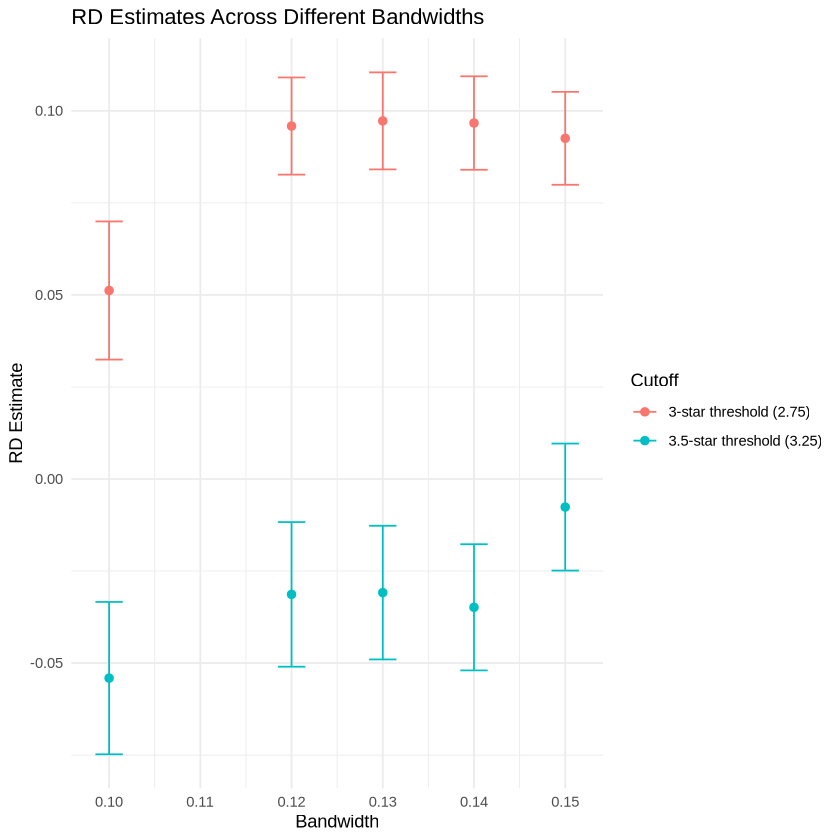

In [46]:
library(tibble)

estimate_rd <- function(data, cutoff, bw) {

  rd <- data %>%
    filter(raw_score >= cutoff - bw,
           raw_score <= cutoff + bw) %>%
    filter(
      (cutoff == 2.75 & Star_Rating %in% c(2.5, 3.0)) |
      (cutoff == 3.25 & Star_Rating %in% c(3.0, 3.5))
    ) %>%
    mutate(
      treat = as.integer(raw_score >= cutoff),
      score = raw_score - cutoff
    )

  model <- lm(market_share ~ treat + score, data = rd)

  tibble(
    cutoff = cutoff,
    bandwidth = bw,
    estimate = unname(coef(model)["treat"]),
    se = summary(model)$coefficients["treat", "Std. Error"]
  )
}

bandwidths <- c(0.10, 0.12, 0.13, 0.14, 0.15)

# These are the TRUE raw-score thresholds for rounding:
# 3.0 stars threshold = 2.75
# 3.5 stars threshold = 3.25
cutoffs <- c(2.75, 3.25)

rd_results <- expand.grid(
  cutoff = cutoffs,
  bandwidth = bandwidths
) %>%
  rowwise() %>%
  do(estimate_rd(data_cleaned, .$cutoff, .$bandwidth)) %>%
  ungroup() %>%
  mutate(
    ci_low = estimate - 1.96 * se,
    ci_high = estimate + 1.96 * se,
    cutoff_label = factor(cutoff,
                          levels = c(2.75, 3.25),
                          labels = c("3-star threshold (2.75)", "3.5-star threshold (3.25)"))
  )

ggplot(rd_results, aes(x = bandwidth, y = estimate, color = cutoff_label)) +
  geom_point(size = 2) +
  geom_errorbar(aes(ymin = ci_low, ymax = ci_high), width = 0.003) +
  labs(
    title = "RD Estimates Across Different Bandwidths",
    x = "Bandwidth",
    y = "RD Estimate",
    color = "Cutoff"
  ) +
  theme_minimal()

My results are somewhat sensitive to the choice of bandwidth, tending to increase slightly as the bandwidth increases. The effect of receiving a 3-star rating on enrollments is around 0.05, but increases as the bandwidth increases. The effect of receiving a 3.5 star rating is negative for all bandwidth values, but increases slightly with bandwidth. 

## Question 8

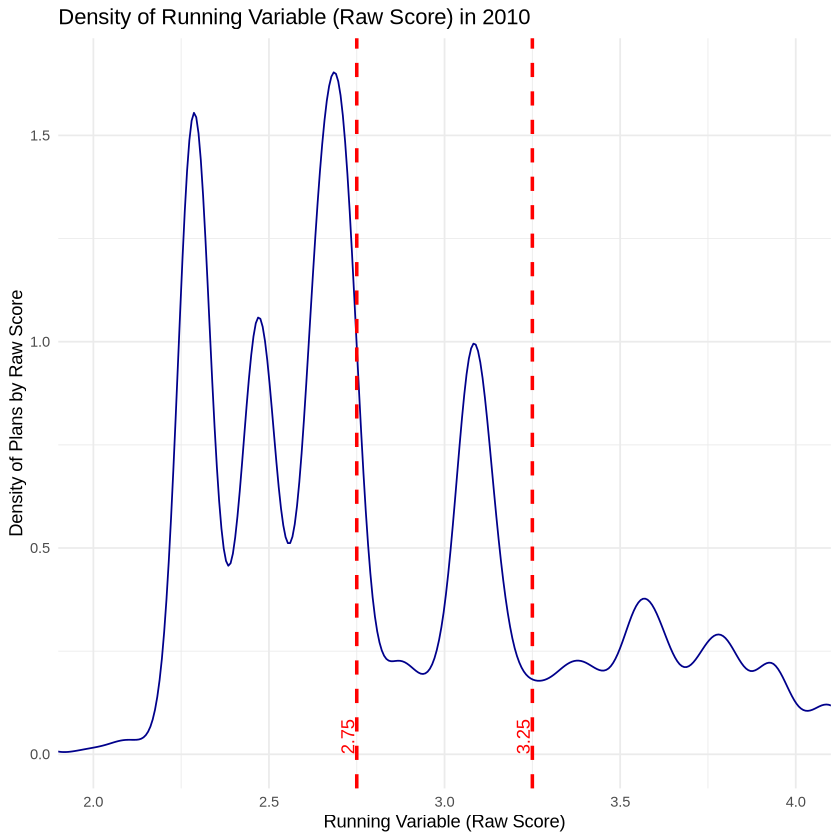

In [23]:
# Question 8

thresholds <- c(2.75, 3.25)

ggplot(data_cleaned %>% filter(is.finite(raw_score)), aes(x = raw_score)) +
  geom_density(alpha = 0.3, color = "darkblue") +

  geom_vline(xintercept = thresholds,
             linetype = "dashed",
             color = "red",
             linewidth = 1) +

  annotate("text", x = 2.75, y = 0, label = "2.75",
           angle = 90, color = "red", vjust = -0.2, hjust = 0) +
  annotate("text", x = 3.25, y = 0, label = "3.25",
           angle = 90, color = "red", vjust = -0.2, hjust = 0) +


  coord_cartesian(xlim = c(2.0, 4.0)) +

  theme_minimal() +
  labs(
    title = "Density of Running Variable (Raw Score) in 2010",
    x = "Running Variable (Raw Score)",
    y = "Density of Plans by Raw Score"
  )

The distrubution of the running variable does not seem to change meaningfully before vs. after the 3.0 and 3.5 thresholds. There is no clear spike immediately to the right of the thresholds, so there is not strong evidence that contracts manipulate the running variable.

## Question 9

Cutoff,Characteristic,Diff
<chr>,<chr>,<dbl>
3.0 stars,HMO,0.42716545
3.0 stars,PartD,0.29107216
3.5 stars,HMO,-0.22885889
3.5 stars,PartD,-0.04690552


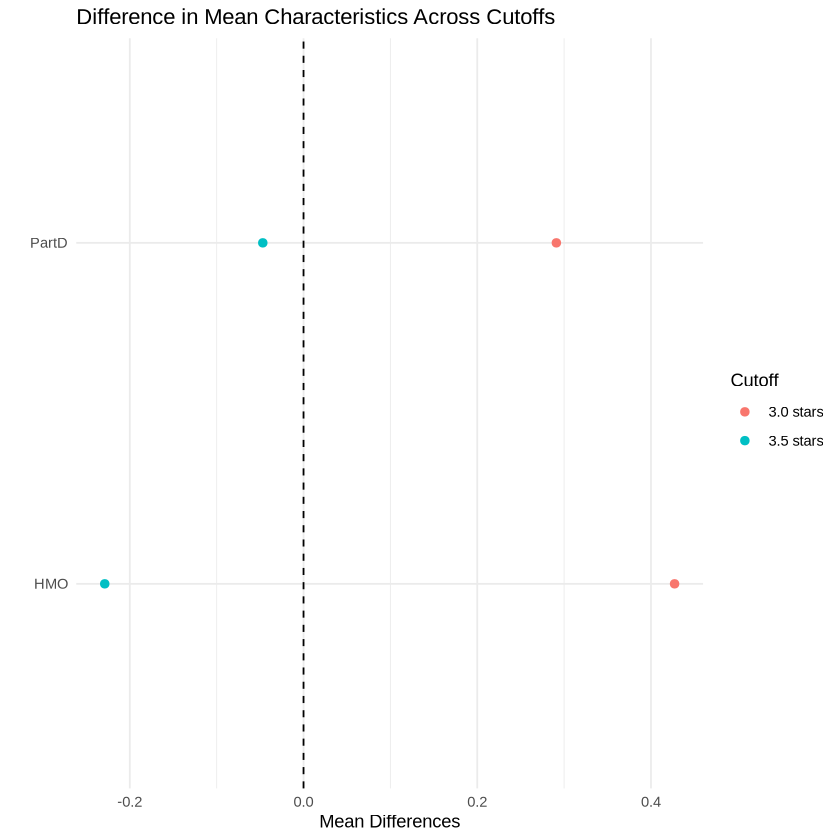

In [33]:
bw <- 0.125
cutoffs <- c(`3.0 stars` = 2.75, `3.5 stars` = 3.25)

# indicators
data_cleaned <- data_cleaned %>%
  mutate(
    HMO = as.integer(grepl("HMO", plan_type)),
    PartD = as.integer(partd == "Yes")
  )

balance_simple <- purrr::imap_dfr(cutoffs, function(cut, label){

  d <- data_cleaned %>%
    filter(is.finite(raw_score),
           raw_score >= cut - bw,
           raw_score <= cut + bw) %>%
    mutate(side = if_else(raw_score >= cut, "Above", "Below"))

  # mean proportions on each side + difference (Above - Below)
  means <- d %>%
    group_by(side) %>%
    summarize(
      HMO = mean(HMO, na.rm = TRUE),
      PartD = mean(PartD, na.rm = TRUE),
      n = n(),
      .groups = "drop"
    ) %>%
    select(-n) %>%
    pivot_longer(cols = c(HMO, PartD), names_to = "Characteristic", values_to = "Mean")

  diff <- means %>%
    pivot_wider(names_from = side, values_from = Mean) %>%
    mutate(
      Cutoff = label,
      Diff = Above - Below
    ) %>%
    select(Cutoff, Characteristic, Diff)

  diff
})

balance_simple

ggplot(balance_simple, aes(x = Diff, y = Characteristic, color = Cutoff)) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  geom_point(size = 2) +
  labs(
    title = "Difference in Mean Characteristics Across Cutoffs",
    x = "Mean Differences",
    y = ""
  ) +
  theme_minimal()

The table and love plot indicate that around 40% more plans are HMOs at the 3-star threshold vs 2.5-stars. Also, plans just above the 3.0 threshold are more likely to have Part D. In contrast, the differences for the 3.5 star threshold are negative but smaller in magnitude. This suggests some differences in HMO and Part D status near the 3-star threshold but not as much evidence of differences at the 3.5 star threshold.

## Question 10

Based on my current analysis, increasing a star rating has a slight positive effect on enrollments at the 3-star threshold but a small negative effect at the 3.5-star threshold. The RD estimate at 3 stars is around 0.05 and statistically significant, while the estimate at 3.5 stars is around -0.04 and significant. The results are somewhat similar across bandwidths, though the effect of receiving 3 stars increases slightly as bandwidth increases. There is no clear evidence of manipulation of the running variable, though plans just above the 3-star threshold are more likely to be HMOs.